# Task 3 - Step 3: Final Sketch evaluation (first and only Sketch access in Task 3)

`shared.pacs.load_target_labels(freeze_manifest)` first re-hashes every checkpoint, config, summary, the split and the
sharpness batch from notebook 02, and refuses if anything changed; each access is logged. Only then are the Sketch
images loaded and predicted. Nothing computed here feeds back into any Task 3 setting. The main comparison stays at
λ_DG = 1 and ρ = 0.05 whatever the study shows.

This notebook also compares Task 3 with the corresponding **Task 2** results: target-aware DAN vs target-free DAN-DG,
with the shared ERM / Source-only baseline.

In [1]:
# ---- Task 3 common header (identical in every Task 3 notebook) ----
# NOTE: this header never loads any Sketch image or label. Only notebook 03 does, after the freeze check.
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "shared" / "pacs.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared import pacs, pacs_protocol as proto
from shared.config import load_config

T3 = REPO / "task3"
CFG_DIR = T3 / "configs"
EVAL_CFG = __import__("yaml").safe_load((CFG_DIR / "evaluation.yaml").read_text())
SEED = 6304
# Smoke mode (env TASK3_SMOKE=1): 2 epochs x 5 updates per trained run, outputs under _smoke/, and notebook 03 uses
# RANDOM stand-in images and labels, so no Sketch image or label is touched.
SMOKE = os.environ.get("TASK3_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T3 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T3 / "results" / "tables"      # protocol/data-prep files from notebook 00 (same in smoke and real mode)
DATA_TAB.mkdir(parents=True, exist_ok=True)
CKPT = T3 / "checkpoints" / SUB            # git-ignored
CACHE = T3 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ERM_DIR = REPO / "task2" / "checkpoints" / "source_only"      # ERM = Task 2 Source-only, loaded, never retrained
TRAIN_RUNS = ["dan_dg", "sam", "dan_dg_lambda0.1", "dan_dg_lambda10"]
MAIN_RUNS = ["erm", "dan_dg", "sam"]
STUDY_RUNS = ["dan_dg_lambda0.1", "dan_dg", "dan_dg_lambda10"]    # controlled study: lambda_DG in {0.1, 1, 10}
ALL_RUNS = ["erm", "dan_dg", "sam", "dan_dg_lambda0.1", "dan_dg_lambda10"]
RUN_NAME = {c: load_config(CFG_DIR, c)["run_name"] for c in ALL_RUNS}
LABEL = {"erm": "ERM", "dan_dg": "DAN-DG (λ=1)", "sam": "SAM (ρ=0.05)",
         "dan_dg_lambda0.1": "DAN-DG (λ=0.1)", "dan_dg_lambda10": "DAN-DG (λ=10)"}


def run_dir(n):
    return ERM_DIR if n == "erm" else CKPT / RUN_NAME[n]


def load_trained(n):
    """Model with the selected checkpoint of run ``n`` (ERM: the Task 2 Source-only checkpoint)."""
    from shared.models import build_model
    ck = torch.load(run_dir(n) / "best.pt", map_location="cpu", weights_only=False)
    model = build_model(7, SEED)
    model.load_state_dict(ck["model"])
    return model.to(DEVICE).eval(), ck


plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
from shared.evaluation import cls_metrics, confusion, per_class_accuracy, predict

CLASSES = pacs.class_names()
if SMOKE:
    g = torch.Generator().manual_seed(0)
    x_t = torch.randint(0, 256, (64, 3, 256, 256), dtype=torch.uint8, generator=g)
    y_t = np.random.default_rng(0).integers(0, 7, size=64)
    print("SMOKE MODE: random stand-in images and labels - no Sketch data touched")
else:
    y_t = pacs.load_target_labels(CACHE / "freeze_manifest.json").numpy()   # verifies the freeze, logs the access
    x_t = pacs.load_target_images()
PRED = {}
for n in ALL_RUNS:
    model, _ = load_trained(n)
    PRED[n] = predict(model, x_t, DEVICE)[1].argmax(1).numpy()
    del model
SRC = pd.read_csv(TAB / "task3_source_validation.csv").set_index("config")
SEP = pd.read_csv(TAB / "task3_domain_separability.csv").set_index("config")
SHARP = pd.read_csv(TAB / "task3_sharpness.csv").set_index("config")
print("Sketch images:", len(y_t))

Sketch images: 3929


In [3]:
# Consistency check: ERM here is the Task 2 Source-only checkpoint, so its Sketch accuracy must equal Task 2's value.
t2 = REPO / "results" / "task2" / "task2_method_comparison.csv"
ERM_CHECK = None
if t2.exists() and not SMOKE:
    t2_so = pd.read_csv(t2).set_index("config").loc["source_only", "target_acc"]
    ERM_CHECK = {"task3_erm_sketch_acc": float((PRED["erm"] == y_t).mean()), "task2_source_only_sketch_acc": float(t2_so)}
    ERM_CHECK["identical"] = abs(ERM_CHECK["task3_erm_sketch_acc"] - ERM_CHECK["task2_source_only_sketch_acc"]) < 1e-12
    print(ERM_CHECK)

{'task3_erm_sketch_acc': 0.6747263934843472, 'task2_source_only_sketch_acc': 0.6747263934843472, 'identical': True}


## 3.1 Method comparison (required table)

In [4]:
TGT = {n: cls_metrics(y_t, PRED[n]) for n in ALL_RUNS}
rows = []
for n in ALL_RUNS:
    rows.append({"config": n, "method": LABEL[n],
                 **{c: SRC.loc[n, c] for c in SRC.columns if c.endswith("_acc") or c.endswith("_macro_f1")},
                 "worst_domain_by_acc": SRC.loc[n, "worst_domain_by_acc"],
                 "sketch_acc": TGT[n]["acc"], "sketch_macro_f1": TGT[n]["macro_f1"],
                 "sketch_acc_change_vs_erm": TGT[n]["acc"] - TGT["erm"]["acc"],
                 "sketch_macro_f1_change_vs_erm": TGT[n]["macro_f1"] - TGT["erm"]["macro_f1"],
                 "source_domain_separability": SEP.loc[n, "separability_acc"], "sharpness_delta": SHARP.loc[n, "delta_sharp"]})
COMP = pd.DataFrame(rows)
COMP.to_csv(TAB / "task3_method_comparison.csv", index=False)
COMP[COMP.config.isin(MAIN_RUNS)][["method", "photo_acc", "art_painting_acc", "cartoon_acc", "mean_acc", "worst_acc", "mean_macro_f1",
    "worst_macro_f1", "sketch_acc", "sketch_macro_f1", "sketch_acc_change_vs_erm", "source_domain_separability", "sharpness_delta"]].round(4)

,method,photo_acc,art_painting_acc,cartoon_acc,mean_acc,worst_acc,mean_macro_f1,worst_macro_f1,sketch_acc,sketch_macro_f1,sketch_acc_change_vs_erm,source_domain_separability,sharpness_delta
0,ERM,0.9551,0.9073,0.9403,0.9342,0.9073,0.9317,0.9040,0.6747,0.6718,0.0000,0.8870,0.2839
1,DAN-DG (λ=1),0.2575,0.2195,0.1727,0.2166,0.1727,0.0507,0.0421,0.0407,0.0112,-0.6340,0.3322,0.0097
2,SAM (ρ=0.05),0.9760,0.9390,0.9574,0.9575,0.9390,0.9578,0.9387,0.6007,0.6264,-0.0741,0.8904,0.0812


## 3.2 Do mean-source / worst-source validation predict Sketch? (all runs, RQ1)

saved figure task3_source_vs_sketch


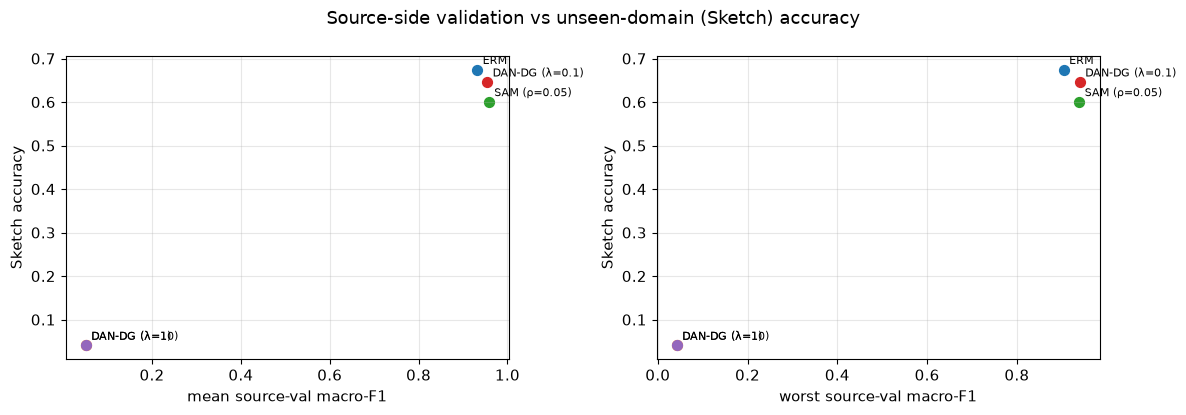

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, t in [(axes[0], "mean_macro_f1", "mean source-val macro-F1"), (axes[1], "worst_macro_f1", "worst source-val macro-F1")]:
    for _, r in COMP.iterrows():
        ax.scatter(r[col], r["sketch_acc"], s=50)
        ax.annotate(r["method"], (r[col], r["sketch_acc"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel(t); ax.set_ylabel("Sketch accuracy"); ax.grid(alpha=.3)
fig.suptitle("Source-side validation vs unseen-domain (Sketch) accuracy")
plt.tight_layout(); savefig(fig, "task3_source_vs_sketch"); plt.show()

## 3.3 Per-class Sketch accuracy, confusions, largest gains / losses

saved figure task3_per_class_sketch_change


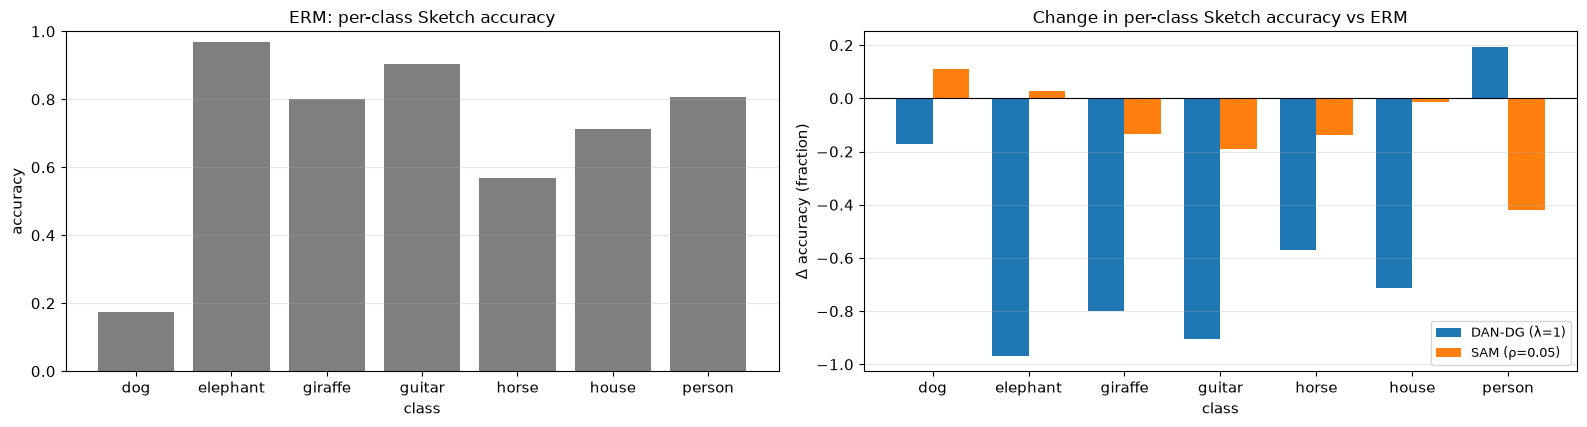

method,ERM,DAN-DG (λ=1),SAM (ρ=0.05),DAN-DG (λ=0.1),DAN-DG (λ=10)
class,,,,,
dog,0.174,0.0,0.282,0.488,0.0
elephant,0.968,0.0,0.993,0.947,0.0
giraffe,0.799,0.0,0.667,0.680,0.0
guitar,0.903,0.0,0.714,0.780,0.0
horse,0.569,0.0,0.433,0.402,0.0
house,0.712,0.0,0.700,0.600,0.0
person,0.806,1.0,0.388,0.612,1.0


In [6]:
PC = {n: per_class_accuracy(y_t, PRED[n], CLASSES) for n in ALL_RUNS}
CLS = pd.DataFrame([{"config": n, "method": LABEL[n], "class": c, "n_sketch": int((y_t == CLASSES.index(c)).sum()),
                     "sketch_acc": PC[n][c], "change_vs_erm": (PC[n][c] - PC["erm"][c]) if PC[n][c] is not None else None}
                    for n in ALL_RUNS for c in CLASSES])
CLS.to_csv(TAB / "task3_class_analysis.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
x = np.arange(len(CLASSES))
axes[0].bar(x, [PC["erm"][c] or 0 for c in CLASSES], color="tab:gray"); axes[0].set_title("ERM: per-class Sketch accuracy"); axes[0].set_ylim(0, 1)
for i, n in enumerate(["dan_dg", "sam"]):
    axes[1].bar(x + (i - .5) * .38, [(PC[n][c] or 0) - (PC["erm"][c] or 0) for c in CLASSES], .38, label=LABEL[n])
axes[1].axhline(0, color="k", lw=.8); axes[1].legend(); axes[1].set_title("Change in per-class Sketch accuracy vs ERM")
for ax, yl in zip(axes, ["accuracy", "Δ accuracy (fraction)"]):
    ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_xlabel("class"); ax.set_ylabel(yl); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "task3_per_class_sketch_change"); plt.show()
CLS.pivot(index="class", columns="method", values="sketch_acc")[[LABEL[n] for n in ALL_RUNS]].round(3)

saved figure task3_confusions


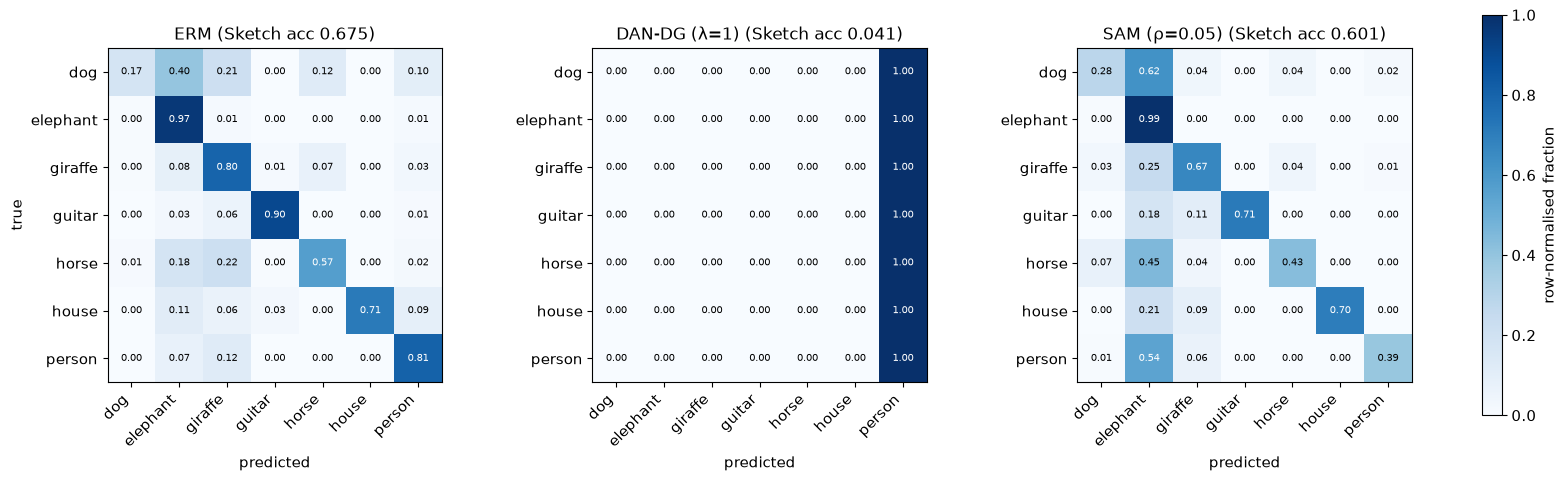

In [7]:
CM = {n: confusion(y_t, PRED[n]) for n in ALL_RUNS}
pd.DataFrame([{"config": n, "true": CLASSES[i], "pred": CLASSES[j], "count": int(CM[n][i, j])}
              for n in ALL_RUNS for i in range(7) for j in range(7)]).to_csv(TAB / "task3_confusions.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={"wspace": 0.45})
for ax, n in zip(axes, MAIN_RUNS):
    m = CM[n] / np.maximum(CM[n].sum(1, keepdims=True), 1)
    im = ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if m[i, j] > .5 else "black")
    ax.set_xticks(range(7)); ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticks(range(7)); ax.set_yticklabels(CLASSES)
    ax.set_title(f"{LABEL[n]} (Sketch acc {TGT[n]['acc']:.3f})"); ax.set_xlabel("predicted")
axes[0].set_ylabel("true"); fig.colorbar(im, ax=axes, fraction=.015, label="row-normalised fraction")
savefig(fig, "task3_confusions"); plt.show()

In [8]:
def dominant_confusion(n, cls):
    i = CLASSES.index(cls); row = CM[n][i].copy(); row[i] = 0; j = int(row.argmax())
    return f"{CLASSES[j]} ({int(row[j])})"

rows, flips = [], []
erm_ok = PRED["erm"] == y_t
for n in [r for r in ALL_RUNS if r != "erm"]:
    delta = {c: PC[n][c] - PC["erm"][c] for c in CLASSES if PC[n][c] is not None}
    for kind, c in [("largest_improvement", max(delta, key=delta.get)), ("largest_degradation", min(delta, key=delta.get))]:
        rows.append({"config": n, "method": LABEL[n], "kind": kind, "class": c, "erm_acc": PC["erm"][c], "method_acc": PC[n][c],
                     "change": delta[c], "erm_top_confusion": dominant_confusion("erm", c), "method_top_confusion": dominant_confusion(n, c)})
    ok = PRED[n] == y_t
    flips.append({"config": n, "method": LABEL[n], "positive_flips": int((~erm_ok & ok).sum()), "negative_flips": int((erm_ok & ~ok).sum()),
                  "both_correct": int((erm_ok & ok).sum()), "both_wrong": int((~erm_ok & ~ok).sum()), "net_change": int(ok.sum() - erm_ok.sum())})
pd.DataFrame(rows).to_csv(TAB / "task3_transfer_cases.csv", index=False)
pd.DataFrame(flips).to_csv(TAB / "task3_prediction_flips.csv", index=False)
pd.DataFrame(rows).round(3)

,config,method,kind,class,erm_acc,method_acc,change,erm_top_confusion,method_top_confusion
0,dan_dg,DAN-DG (λ=1),largest_improvement,person,0.806,1.000,0.194,giraffe (19),dog (0)
1,dan_dg,DAN-DG (λ=1),largest_degradation,elephant,0.968,0.000,-0.968,giraffe (10),person (740)
2,sam,SAM (ρ=0.05),largest_improvement,dog,0.174,0.282,0.109,elephant (305),elephant (480)
3,sam,SAM (ρ=0.05),largest_degradation,person,0.806,0.388,-0.419,giraffe (19),elephant (87)
4,dan_dg_lambda0.1,DAN-DG (λ=0.1),largest_improvement,dog,0.174,0.488,0.315,elephant (305),elephant (228)
5,dan_dg_lambda0.1,DAN-DG (λ=0.1),largest_degradation,person,0.806,0.612,-0.194,giraffe (19),elephant (42)
6,dan_dg_lambda10,DAN-DG (λ=10),largest_improvement,person,0.806,1.000,0.194,giraffe (19),dog (0)
7,dan_dg_lambda10,DAN-DG (λ=10),largest_degradation,elephant,0.968,0.000,-0.968,giraffe (10),person (740)


### Failure examples (spread over classes)

For DAN-DG and SAM: for each class, the first Sketch image (by index) that ERM gets right and the method gets wrong
(negative flip), and the first that ERM gets wrong and the method gets right (positive flip). This avoids showing only
the first class in file order. The rule is fixed and does not pick by score.

saved figure task3_failure_cases


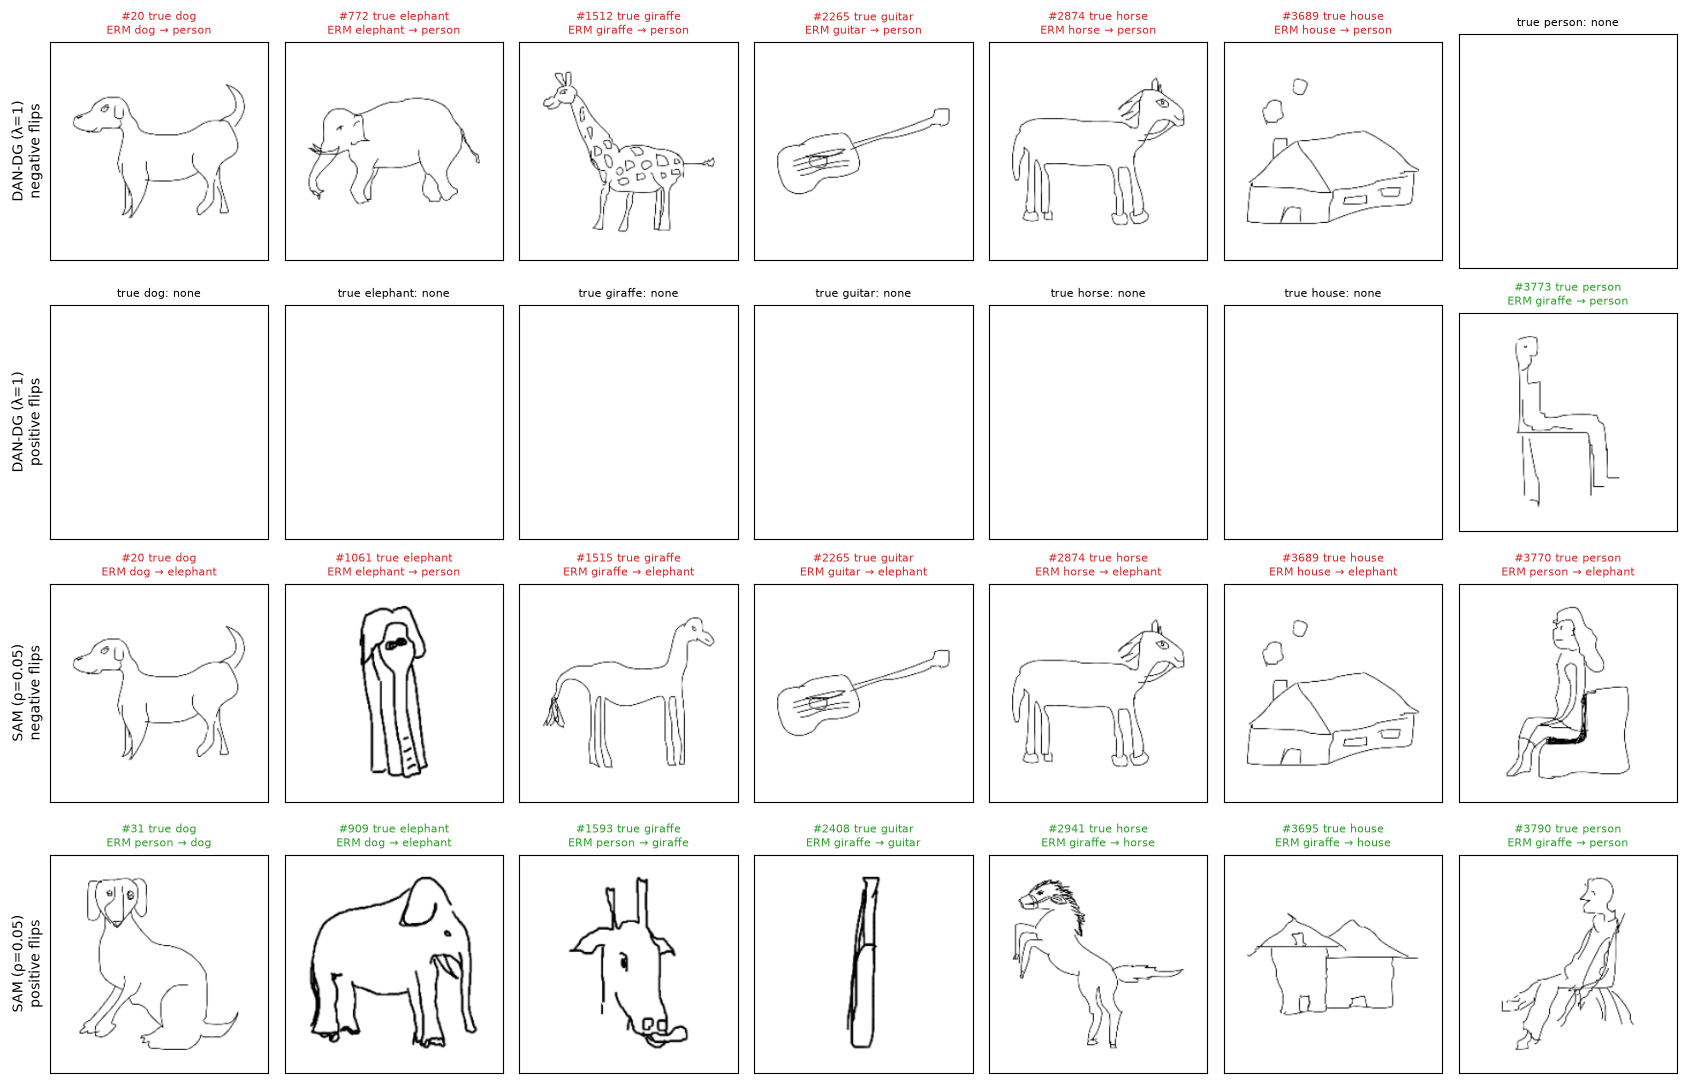

In [9]:
fig, axes = plt.subplots(4, 7, figsize=(17, 11))
ex = []
for r, (n, kind) in enumerate([(m, k) for m in ["dan_dg", "sam"] for k in ("negative", "positive")]):
    for c in range(7):
        mask = (y_t == c) & ((erm_ok & (PRED[n] != y_t)) if kind == "negative" else (~erm_ok & (PRED[n] == y_t)))
        ax = axes[r, c]; ax.set_xticks([]); ax.set_yticks([])
        idx = np.flatnonzero(mask)
        if len(idx):
            i = int(idx[0])
            ax.imshow(x_t[i].permute(1, 2, 0).numpy())
            ax.set_title(f"#{i} true {CLASSES[c]}\nERM {CLASSES[PRED['erm'][i]]} → {CLASSES[PRED[n][i]]}", fontsize=8,
                         color="tab:red" if kind == "negative" else "tab:green")
            ex.append({"config": n, "kind": kind, "sketch_index": i, "true": CLASSES[c], "erm_pred": CLASSES[PRED["erm"][i]], "method_pred": CLASSES[PRED[n][i]]})
        else:
            ax.set_title(f"true {CLASSES[c]}: none", fontsize=8)
        if c == 0:
            ax.set_ylabel(f"{LABEL[n]}\n{kind} flips", fontsize=10)
pd.DataFrame(ex).to_csv(TAB / "task3_failure_examples.csv", index=False)
plt.tight_layout(); savefig(fig, "task3_failure_cases"); plt.show()

## 3.4 Controlled study: DAN-DG λ ∈ {0.1, 1, 10}

`best_mean_source_val_f1` marks the λ that source validation alone would choose. It is recorded, not used; the main
comparison stays at λ_DG = 1.

saved figure task3_controlled_study


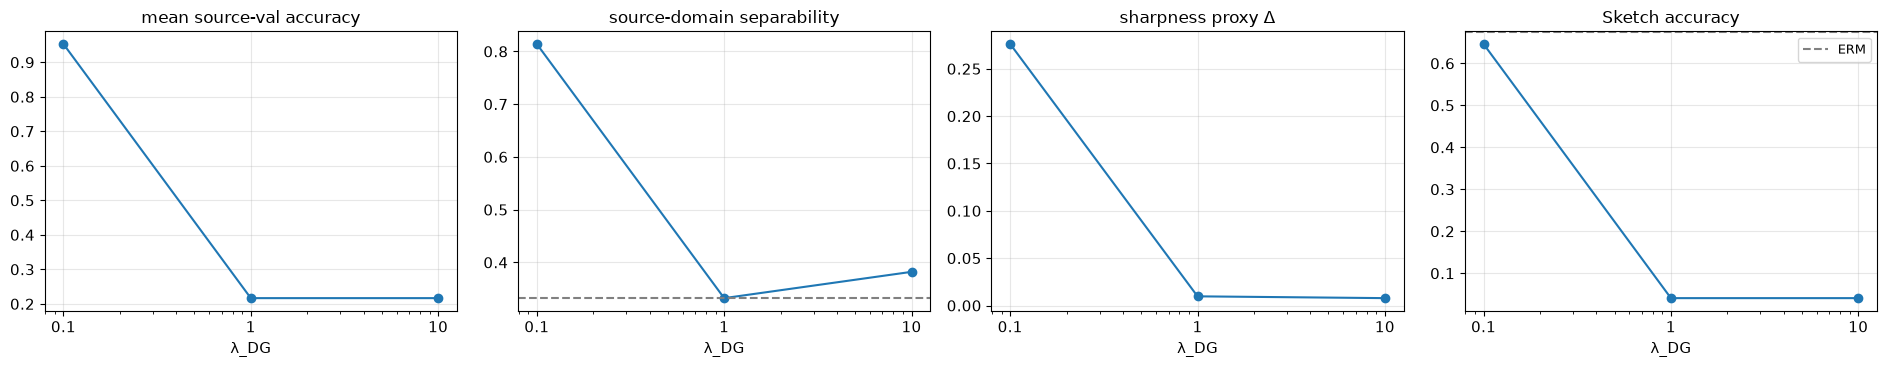

,lambda_dg,mean_acc,mean_macro_f1,worst_acc,source_domain_separability,sharpness_delta,sketch_acc,sketch_macro_f1,sketch_acc_change_vs_erm,best_mean_source_val_f1
3,0.1,0.9528,0.9542,0.9366,0.8140,0.2761,0.6460,0.6369,-0.0288,True
1,1.0,0.2166,0.0507,0.1727,0.3322,0.0097,0.0407,0.0112,-0.6340,False
4,10.0,0.2166,0.0507,0.1727,0.3821,0.0078,0.0407,0.0112,-0.6340,False


In [10]:
lam = {"dan_dg_lambda0.1": 0.1, "dan_dg": 1.0, "dan_dg_lambda10": 10.0}
ST = COMP[COMP.config.isin(STUDY_RUNS)].assign(lambda_dg=lambda d: d.config.map(lam)).sort_values("lambda_dg")
ST["best_mean_source_val_f1"] = ST.mean_macro_f1 == ST.mean_macro_f1.max()
ST = ST[["lambda_dg", "mean_acc", "mean_macro_f1", "worst_acc", "source_domain_separability", "sharpness_delta", "sketch_acc",
         "sketch_macro_f1", "sketch_acc_change_vs_erm", "best_mean_source_val_f1"]]
ST.to_csv(TAB / "task3_controlled_study.csv", index=False)
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
for ax, col, t in [(axes[0], "mean_acc", "mean source-val accuracy"), (axes[1], "source_domain_separability", "source-domain separability"),
                   (axes[2], "sharpness_delta", "sharpness proxy Δ"), (axes[3], "sketch_acc", "Sketch accuracy")]:
    ax.plot(ST.lambda_dg, ST[col], marker="o"); ax.set_xscale("log"); ax.set_xticks([0.1, 1, 10]); ax.set_xticklabels(["0.1", "1", "10"])
    ax.set_xlabel("λ_DG"); ax.set_title(t); ax.grid(alpha=.3)
axes[1].axhline(1 / 3, ls="--", color="gray")
axes[3].axhline(TGT["erm"]["acc"], ls="--", color="gray", label="ERM"); axes[3].legend()
plt.tight_layout(); savefig(fig, "task3_controlled_study"); plt.show()
ST.round(4)

## 3.5 Comparison with Task 2: target-aware DAN vs target-free DAN-DG (shared ERM baseline)

Task 2's Source-only model is Task 3's ERM. Task 2's DAN aligns sources with **unlabelled Sketch**; Task 3's DAN-DG
aligns the **three sources with each other**. Both use the same MMD function and λ grid. This is a comparison of
results, not a causal attribution: the two objectives differ in more than target access (what is aligned, batch
composition, pair structure).

saved figure task3_dan_vs_dandg


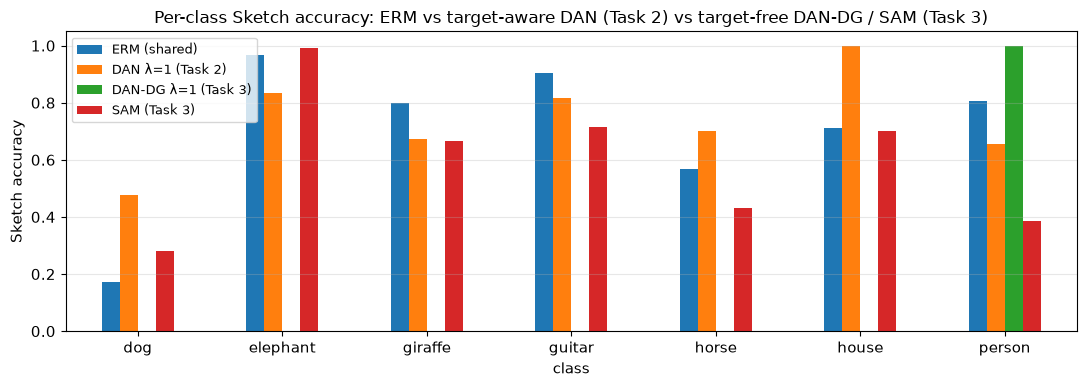

,model,task,target_images_used,sketch_acc,sketch_macro_f1,source_val_mean_acc,lambda,separability_note
0,ERM = Task 2 Source-only (shared),2/3,False,0.6747,0.6718,0.9342,NaN,NaN
1,"DAN λ=0.1 (Task 2, target-aware)",2,True,0.7193,0.6632,0.9393,0.1,source-vs-Sketch: 0.964
2,"DAN λ=1.0 (Task 2, target-aware)",2,True,0.6989,0.6373,0.9437,1.0,source-vs-Sketch: 0.852
3,"DAN λ=10.0 (Task 2, target-aware)",2,True,0.0407,0.0112,0.2166,10.0,source-vs-Sketch: 0.654
4,"DAN-DG λ=0.1 (Task 3, target-free)",3,False,0.6460,0.6369,0.9528,0.1,3-way source: 0.814
5,"DAN-DG λ=1.0 (Task 3, target-free)",3,False,0.0407,0.0112,0.2166,1.0,3-way source: 0.332
6,"DAN-DG λ=10.0 (Task 3, target-free)",3,False,0.0407,0.0112,0.2166,10.0,3-way source: 0.382


120

In [11]:
t2c, t2k = REPO / "results" / "task2" / "task2_method_comparison.csv", REPO / "results" / "task2" / "task2_class_analysis.csv"
if t2c.exists() and not SMOKE:
    c2 = pd.read_csv(t2c).set_index("config")
    rows = [{"model": "ERM = Task 2 Source-only (shared)", "task": "2/3", "target_images_used": False,
             "sketch_acc": TGT["erm"]["acc"], "sketch_macro_f1": TGT["erm"]["macro_f1"], "source_val_mean_acc": COMP.set_index("config").loc["erm", "mean_acc"]}]
    for cfg2, lam_ in [("dan_lambda0.1", 0.1), ("dan", 1.0), ("dan_lambda10", 10.0)]:
        rows.append({"model": f"DAN λ={lam_} (Task 2, target-aware)", "task": "2", "target_images_used": True, "lambda": lam_,
                     "sketch_acc": c2.loc[cfg2, "target_acc"], "sketch_macro_f1": c2.loc[cfg2, "target_macro_f1"],
                     "source_val_mean_acc": c2.loc[cfg2, "mean_acc"], "separability_note": "source-vs-Sketch: %.3f" % c2.loc[cfg2, "domain_separability"]})
    for cfg3, lam_ in [("dan_dg_lambda0.1", 0.1), ("dan_dg", 1.0), ("dan_dg_lambda10", 10.0)]:
        r3 = COMP.set_index("config").loc[cfg3]
        rows.append({"model": f"DAN-DG λ={lam_} (Task 3, target-free)", "task": "3", "target_images_used": False, "lambda": lam_,
                     "sketch_acc": r3["sketch_acc"], "sketch_macro_f1": r3["sketch_macro_f1"], "source_val_mean_acc": r3["mean_acc"],
                     "separability_note": "3-way source: %.3f" % r3["source_domain_separability"]})
    T2CMP = pd.DataFrame(rows)
    T2CMP.to_csv(TAB / "task3_task2_comparison.csv", index=False)
    k2 = pd.read_csv(t2k)
    k2 = k2[k2.config == "dan"].set_index("class")["target_acc"]
    PCC = pd.DataFrame({"ERM (shared)": {c: PC["erm"][c] for c in CLASSES}, "DAN λ=1 (Task 2)": k2.to_dict(),
                        "DAN-DG λ=1 (Task 3)": {c: PC["dan_dg"][c] for c in CLASSES}, "SAM (Task 3)": {c: PC["sam"][c] for c in CLASSES}})
    PCC.to_csv(TAB / "task3_task2_class_comparison.csv")
    fig, ax = plt.subplots(figsize=(11, 4))
    PCC.plot.bar(ax=ax); ax.set_ylabel("Sketch accuracy"); ax.set_xlabel("class"); ax.set_ylim(0, 1.05)
    ax.set_title("Per-class Sketch accuracy: ERM vs target-aware DAN (Task 2) vs target-free DAN-DG / SAM (Task 3)")
    ax.tick_params(axis="x", rotation=0); ax.grid(axis="y", alpha=.3)
    plt.tight_layout(); savefig(fig, "task3_dan_vs_dandg"); plt.show()
    display(T2CMP.round(4))
else:
    print("Task 2 results not available (or smoke mode): comparison skipped")
(TAB / "task3_erm_consistency.json").write_text(json.dumps(ERM_CHECK, indent=1))